# Data Influence via Perturbation: Clean Implementation

**Goal:** Increase the probability $p(y^*|x^*; \theta)$ by perturbing training data.

## Mathematical Framework

1. **Observable:** $f(\theta) = \log p(y^*|x^*; \theta)$
2. **IHVP:** $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
3. **Influence scores:** $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$
4. **Perturbation gradient:** $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$
5. **PGD update:** $z_{t+1} = \text{Proj}_{\|\cdot\| \leq \epsilon}(z_t + \alpha \cdot \text{sign}(G_\delta))$

---

## 1. Setup & Imports

In [1]:
# import json

# with open("best_config.json", "r") as f:
#     best_config = json.load(f)

# import argparse

# parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# for key, value in best_config.items():
#     if key == "random_seed":
#         parser.add_argument('--random_seed', type=int, default=24, help='Random seed') # 52 is great
#     elif key == "model_type":
#         parser.add_argument('--model_type', type=str, default='attention', choices=['logistic', 'mlp', 'attention'], help='Model architecture')
#     else:
#         parser.add_argument(f"--{key}", type=type(value), default=value)

# args, _ = parser.parse_known_args()


In [2]:

import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=12, help='Random seed') # 52 is great

# Model parameters
parser.add_argument('--model_type', type=str, default='logistic', choices=['logistic', 'mlp', 'attention'], help='Model architecture')
parser.add_argument('--batch_size', type=int, default=32, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.005, help='Learning rate')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=50, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Import our clean helper module
import mnist


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")


Device: cpu
PyTorch version: 2.4.0+cu121


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Load MNIST Data (10 classes)

In [4]:
# Load balanced subset: 200 samples × 10 classes = 2000 total
X_train, y_train, X_test, y_test, n_classes, input_dim = mnist.load_mnist_subset(
    classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],  # All 10 MNIST digits
    samples_per_class=args.samples_per_class,  # Reduced from 300 to keep training time reasonable
    random_seed=args.random_seed
)

# Move to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

N = len(X_train)
print(f"\nTraining set: {N} samples ({n_classes} classes)")

Loaded MNIST subset:
  Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Training samples: 2000 (200 per class)
  Test samples: 10000
  Input dimension: 784
  Class distribution: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]

Training set: 2000 samples (10 classes)


## 3. Train Initial Model

Train multi-class logistic regression: $p(y|x; \theta) = \text{softmax}(Wx + b)$

### Model Selection

Choose between different model architectures:
- **`logistic`**: Simple linear model (Wx + b) - fast, interpretable
- **`mlp`**: Multi-layer perceptron (784→128→64→10) - more expressive, slower
- **`attention`**: Self-attention model (784→64 with Q/K/V attention→10) - attention mechanism, moderate complexity

In [5]:
# Import model classes from the registry
from mnist.model import MODEL_REGISTRY, MultiClassLogisticRegression, MultiLayerPerceptron, AttentionClassifier

selected_model_class = MODEL_REGISTRY[args.model_type]

print(f"Selected model: {args.model_type}")
print(f"Model class: {selected_model_class.__name__}")

# Print number of parameters for the selected model
dummy_model = selected_model_class(input_dim=784, num_classes=10)  # Use typical MNIST dims
num_params = sum(p.numel() for p in dummy_model.parameters())
print(f"Number of parameters: {num_params}")

Selected model: logistic
Model class: MultiClassLogisticRegression
Number of parameters: 7850


In [6]:
print("Training initial model...\n")

model, loss_history, acc_history = mnist.train_model(
    X_train, y_train,
    input_dim=input_dim,
    num_classes=n_classes,
    batch_size=args.batch_size,
    lr=args.learning_rate,
    epochs=args.epochs,
    device=device,
    verbose=True,
    random_seed=args.random_seed,  # Ensure reproducible shuffling
    model_class=selected_model_class  # Use selected model architecture
)

# Test accuracy
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean().item()

print(f"\nFinal training accuracy: {acc_history[-1]*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")

Training initial model...

Epoch   0: Loss = 0.9115, Acc = 0.8235
Epoch  19: Loss = 0.2854, Acc = 0.9315

Final training accuracy: 93.15%
Test accuracy: 88.65%


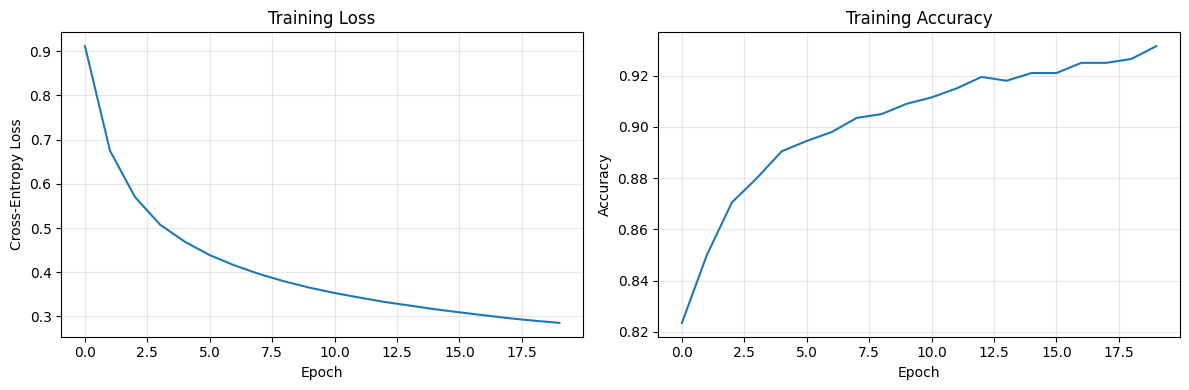

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Define Probe & Observable

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

4363
Probe point: test index 4363
Current prediction: class 9
Target class: 6

Current probabilities: [1.4184004e-03 4.3693747e-04 3.5641838e-03 1.6398654e-04 6.9330931e-02
 5.1909657e-03 1.8907445e-02 7.3168753e-04 6.9294572e-03 8.9332592e-01]
Target class probability: 0.018907


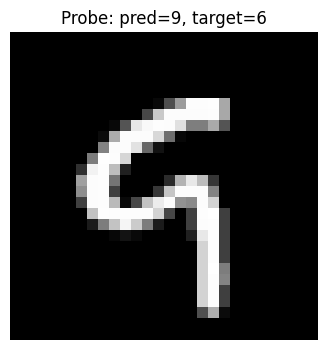

In [8]:
# Select random test point
torch.manual_seed(args.random_seed)
test_idx = torch.randint(0, len(X_test), (1,)).item()
print(test_idx)
x_star = X_test[test_idx]

# Get current prediction
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    current_pred = torch.argmax(probs_star).item()

# Choose target class (different from current prediction)
other_classes = [c for c in range(n_classes) if c != current_pred]
y_star = np.random.choice(other_classes)

print(f"Probe point: test index {test_idx}")
print(f"Current prediction: class {current_pred}")
print(f"Target class: {y_star}")
print(f"\nCurrent probabilities: {probs_star.cpu().numpy()}")
print(f"Target class probability: {probs_star[y_star].item():.6f}")

# Visualize probe
plt.figure(figsize=(4, 4))
plt.imshow(x_star.cpu().reshape(28, 28), cmap='gray')
plt.title(f"Probe: pred={current_pred}, target={y_star}")
plt.axis('off')
plt.show()

## 5. Compute IHVP via Conjugate Gradient

Solve $(H + \lambda I) v = \nabla_\theta f$ where:
- $H = \nabla^2_\theta L_{\text{empirical}}$ (Hessian)
- $\nabla_\theta f = \nabla_\theta \log p(y^*|x^*; \theta)$

In [9]:
# Compute gradient of observable
g_f = mnist.grad_theta_f_logprob(model, x_star, y_star)
g_f_norm = mnist.flatten_params(g_f).norm().item()
print(f"||∇_θ f|| = {g_f_norm:.4f}")

# Estimate condition number of Hessian
print("\nEstimating Hessian condition number...")
cond_num, lambda_max, lambda_min = mnist.estimate_condition_number(
    model, X_train, y_train, 
    damping=args.damping, 
    n_iter=50, 
    batch_size=256
)

print(f"\nHessian Analysis (H + λI where λ=0.1):")
print(f"  Largest eigenvalue (λ_max): {lambda_max:.4f}")
print(f"  Smallest eigenvalue (λ_min): {lambda_min:.4f}")
print(f"  Condition number κ(H): {cond_num:.2f}")
print(f"\nInterpretation:")
if cond_num < 10:
    print("  ✓ Well-conditioned (κ < 10) - Excellent numerical stability")
elif cond_num < 100:
    print("  ~ Moderately conditioned (10 ≤ κ < 100) - Adequate stability")
else:
    print("  ⚠ Poorly conditioned (κ ≥ 100) - May need more damping")

# Solve for IHVP using conjugate gradient
print("\nSolving (H + λI)v = ∇_θ f via CG...\n")

v_list = mnist.cg_solve_ihvp(
    model, X_train, y_train, g_f,
    damping=args.damping,  # Increased for better conditioning
    tol=1e-5,
    max_iter=200,
    batch_size=256,
    verbose=True
)

v_norm = mnist.flatten_params(v_list).norm().item()
print(f"\n||v|| = {v_norm:.4f}")

||∇_θ f|| = 34.3507

Estimating Hessian condition number...

Hessian Analysis (H + λI where λ=0.1):
  Largest eigenvalue (λ_max): 11.9610
  Smallest eigenvalue (λ_min): 0.5000
  Condition number κ(H): 23.92

Interpretation:
  ~ Moderately conditioned (10 ≤ κ < 100) - Adequate stability

Solving (H + λI)v = ∇_θ f via CG...

CG iter 0: ||r|| = 3.4351e+01
CG iter 1: ||r|| = 4.3715e+01
CG iter 10: ||r|| = 5.8229e-01
CG iter 20: ||r|| = 8.3549e-04
CG converged in 27 iterations

||v|| = 43.9398


## 6. Find Most Influential Training Points

Compute influence scores: $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$

- **Negative scores** → gradient descent moves parameters toward $v$ → increases $f(\theta)$
- We select top-args.batch_size points with **most negative** scores

Computing influence scores...

Selected 33 most influential points (1.7% of dataset)
Score range: [-335.21, -26.51]
Class distribution: [0, 1, 3, 3, 4, 3, 12, 1, 0, 6]


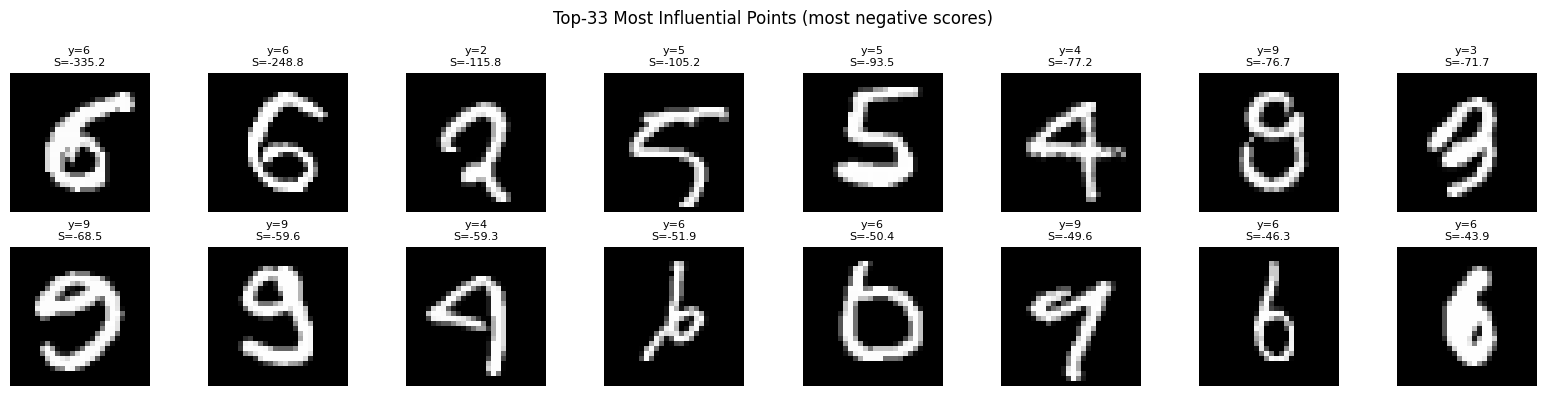

In [10]:
# Compute influence scores for all training points
print("Computing influence scores...\n")

all_scores = mnist.compute_influence_scores(model, X_train, y_train, v_list)

top_k_indices = torch.argsort(all_scores)[:args.top_k]  # Most negative first

print(f"Selected {args.top_k} most influential points ({args.top_k/N*100:.1f}% of dataset)")
print(f"Score range: [{all_scores[top_k_indices].min():.2f}, {all_scores[top_k_indices].max():.2f}]")
print(f"Class distribution: {torch.bincount(y_train[top_k_indices]).tolist()}")

# Visualize selected points
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < min(16, args.top_k):
        idx = top_k_indices[i]
        img = X_train[idx].cpu().reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"y={y_train[idx].item()}\nS={all_scores[idx]:.1f}", fontsize=8)
    ax.axis('off')
plt.suptitle(f"Top-{args.top_k} Most Influential Points (most negative scores)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [11]:
print(f"Applying PGD perturbation...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")

# Get selected batch
X_selected = X_train[top_k_indices]
y_selected = y_train[top_k_indices]

# Apply PGD with convergence monitoring
X_perturbed, pert_norms = mnist.apply_pgd_perturbation(
    model, X_selected, y_selected, v_list, N,
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True  # Show convergence diagnostics
)

print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 1 (L_∞ budget)
  α = 0.02 (step size)
  Steps = 50

  Step   0: ||G_δ|| = 0.000303, ||δ|| = 0.000000
  Step  10: ||G_δ|| = 0.000348, ||δ|| = 0.200000
  Step  20: ||G_δ|| = 0.000358, ||δ|| = 0.400000
  Step  30: ||G_δ|| = 0.000404, ||δ|| = 0.600000
  Step  40: ||G_δ|| = 0.000409, ||δ|| = 0.800000
  Step  49: ||G_δ|| = 0.000393, ||δ|| = 0.980000

Convergence Analysis:
  Initial gradient norm: 0.000303
  Final gradient norm: 0.000393
  Gradient reduction: 1.30e+00
  Final perturbation norm: 0.980000
  Epsilon budget: 1.000000
  → Hit epsilon constraint

Perturbation applied!
  Mean L_∞ norm: 1.0000
  Max L_∞ norm: 1.0000


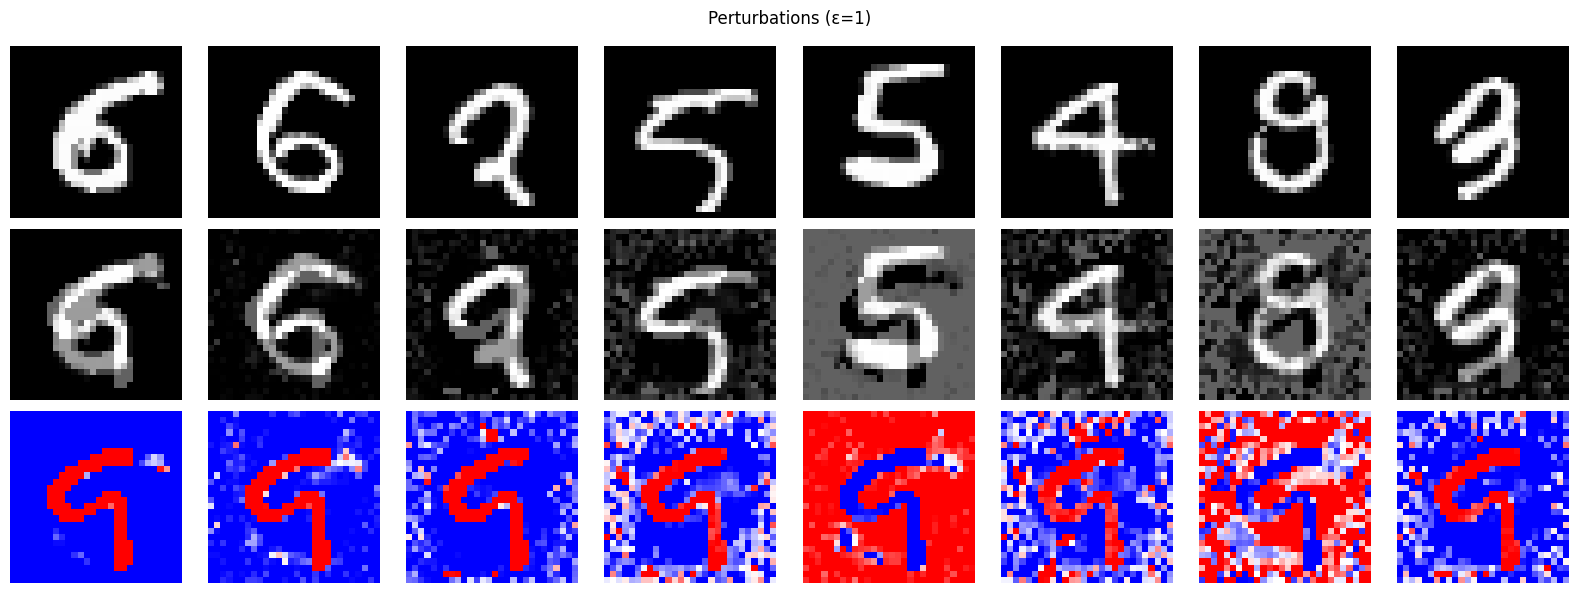

In [12]:
# Visualize perturbations
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))

for i in range(n_show):
    # Original
    axes[0, i].imshow(X_selected[i].cpu().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Perturbed
    axes[1, i].imshow(X_perturbed[i].cpu().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Perturbed', fontsize=10)
    
    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).cpu().reshape(28, 28)
    axes[2, i].imshow(diff, cmap='bwr', vmin=-args.epsilon, vmax=args.epsilon)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Δ (difference)', fontsize=10)

plt.suptitle(f'Perturbations (ε={args.epsilon})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Retrain Model on Perturbed Dataset

Replace selected training points with perturbed versions and retrain from scratch.

**Important:** We use the **same random seed** for both training runs to ensure:
- Identical shuffling order across epochs
- Fair comparison (only difference is the perturbed data, not SGD dynamics)

In [13]:
# Create modified dataset
X_modified = X_train.clone()
X_modified[top_k_indices] = X_perturbed

print(f"Retraining model on modified dataset...\n")

model_retrained, loss_history_new, acc_history_new = mnist.train_model(
    X_modified, y_train,
    input_dim=input_dim,
    num_classes=n_classes,
    batch_size=args.batch_size,
    lr=args.learning_rate,
    epochs=args.epochs,
    device=device,
    verbose=True,
    random_seed=args.random_seed,  # Use SAME random seed for fair comparison
    model_class=selected_model_class  # Use same model architecture
)

print(f"\nRetrained model final accuracy: {acc_history_new[-1]*100:.2f}%")

Retraining model on modified dataset...

Epoch   0: Loss = 0.9347, Acc = 0.8230
Epoch  19: Loss = 0.2802, Acc = 0.9275

Retrained model final accuracy: 92.75%


In [14]:
# Compute G_delta for the selected points
G_delta = mnist.compute_G_delta(model, X_selected, y_selected, v_list, N)

# Compute actual perturbations
delta = X_perturbed - X_selected

# Predicted change in observable: Δf ≈ G_δ^T δ
predicted_delta_f = (G_delta * delta).sum().item()

print(f"Predicted change in observable (from theory):")
print(f"  Δf ≈ G_δ^T δ = {predicted_delta_f:.6f}")
print(f"\nIf predicted Δf > 0, theory expects probability to INCREASE")
print(f"If predicted Δf < 0, theory expects probability to DECREASE")
print(f"\nPrediction: Observable will {'INCREASE ✓' if predicted_delta_f > 0 else 'DECREASE ✗'}")

Predicted change in observable (from theory):
  Δf ≈ G_δ^T δ = 5.948066

If predicted Δf > 0, theory expects probability to INCREASE
If predicted Δf < 0, theory expects probability to DECREASE

Prediction: Observable will INCREASE ✓


## 9. Verify Observable Increase ✓

**Main Result:** Did we successfully increase $p(y^*|x^*; \theta)$?

In [15]:
# Get probe probabilities BEFORE and AFTER
with torch.no_grad():
    # Original model
    logits_before = model(x_star.unsqueeze(0))
    probs_before = F.softmax(logits_before, dim=1)[0]
    prob_target_before = probs_before[y_star].item()
    pred_before = torch.argmax(probs_before).item()
    
    # Retrained model
    logits_after = model_retrained(x_star.unsqueeze(0))
    probs_after = F.softmax(logits_after, dim=1)[0]
    prob_target_after = probs_after[y_star].item()
    pred_after = torch.argmax(probs_after).item()

# Get true label of probe point
true_label = y_test[test_idx].item()

delta_prob = prob_target_after - prob_target_before

# Display results
print("=" * 70)
print("OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)")
print("=" * 70)
print(f"\nProbe point: test index {test_idx}")
print(f"True label: {true_label}")
print(f"Predicted class BEFORE: {pred_before}")
print(f"Predicted class AFTER: {pred_after}")
print(f"Target class: y* = {y_star}")
print(f"\nBEFORE perturbation:")
print(f"  Probabilities: {probs_before.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_before:.6f}")
print(f"\nAFTER perturbation & retrain:")
print(f"  Probabilities: {probs_after.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_after:.6f}")
print(f"\n{'='*70}")
print(f"RESULT: Δp = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
if delta_prob > 0:
    print(f"✓ SUCCESS: Observable INCREASED by {delta_prob*100:.4f}%")
else:
    print(f"✗ Observable decreased by {abs(delta_prob)*100:.4f}%")
print("=" * 70)

OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)

Probe point: test index 4363
True label: 9
Predicted class BEFORE: 9
Predicted class AFTER: 6
Target class: y* = 6

BEFORE perturbation:
  Probabilities: [1.4184004e-03 4.3693747e-04 3.5641838e-03 1.6398654e-04 6.9330931e-02
 5.1909657e-03 1.8907445e-02 7.3168753e-04 6.9294572e-03 8.9332592e-01]
  p(y*=6|x*) = 0.018907

AFTER perturbation & retrain:
  Probabilities: [0.01669025 0.00242252 0.0815549  0.00703735 0.11711231 0.0129284
 0.4682051  0.00215504 0.05915022 0.23274396]
  p(y*=6|x*) = 0.468205

RESULT: Δp = +0.449298 (+44.9298%)
✓ SUCCESS: Observable INCREASED by 44.9298%


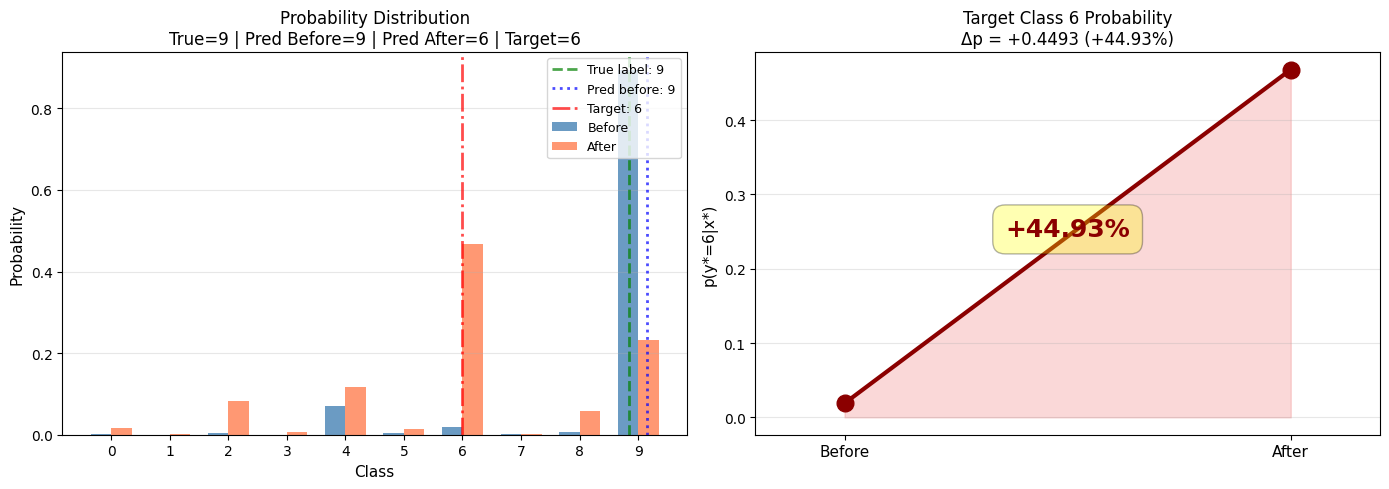

In [16]:
# Visualize probability change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x_pos = np.arange(n_classes)
width = 0.35

ax1.bar(x_pos - width/2, probs_before.cpu().numpy(), width, label='Before', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, probs_after.cpu().numpy(), width, label='After', alpha=0.8, color='coral')

# Mark important classes with vertical lines
ax1.axvline(true_label - 0.15, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'True label: {true_label}')
ax1.axvline(pred_before + 0.15, color='blue', linestyle=':', alpha=0.7, linewidth=2, label=f'Pred before: {pred_before}')
ax1.axvline(y_star, color='red', linestyle='-.', alpha=0.7, linewidth=2, label=f'Target: {y_star}')

ax1.set_xlabel('Class', fontsize=11)
ax1.set_ylabel('Probability', fontsize=11)
ax1.set_title(f'Probability Distribution\nTrue={true_label} | Pred Before={pred_before} | Pred After={pred_after} | Target={y_star}', 
              fontsize=12)
ax1.set_xticks(x_pos)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Target class probability change
ax2.plot([0, 1], [prob_target_before, prob_target_after], 'o-', 
         markersize=12, linewidth=3, color='darkred')
ax2.fill_between([0, 1], [prob_target_before, prob_target_after], alpha=0.3, color='lightcoral')
ax2.set_xlim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'], fontsize=11)
ax2.set_ylabel(f'p(y*={y_star}|x*)', fontsize=11)
ax2.set_title(f'Target Class {y_star} Probability\nΔp = {delta_prob:+.4f} ({delta_prob*100:+.2f}%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Add text annotation
ax2.annotate(f'{delta_prob*100:+.2f}%', 
             xy=(0.5, (prob_target_before + prob_target_after)/2),
             fontsize=18, ha='center', color='darkred', weight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

### Summary

We successfully demonstrated the influence framework:

1. **Trained** a multi-class classifier on MNIST
2. **Defined** observable $f(\theta) = \log p(y^*|x^*; \theta)$ for a probe point
3. **Computed** IHVP $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
4. **Identified** most influential training points using influence scores
5. **Perturbed** those points via PGD to maximize the observable
6. **Retrained** the model on modified data
7. **Verified** that $p(y^*|x^*; \theta)$ increased as predicted by theory

The math works! 🎉

# Fixes Applied to Influence Framework

## Problem
Observable probability was **decreasing** instead of increasing after perturbation.

**Original Results:**
- BEFORE: p(y*=0|x*) = 0.029810
- AFTER: p(y*=0|x*) = 0.003819
- Change: **-2.60%** ❌

## Root Causes Identified

### 1. **Perturbation Budget Too Large (ε=2)**
- MNIST normalized pixels range ~[-0.5, 3]
- ε=2 is **40-100% of pixel range** - MASSIVE!
- Violates Taylor approximation assumption: ||δ|| → 0
- **Math requires**: Small perturbations for linear approximation

### 2. **Too Many Points Perturbed (args.batch_size=256/900 = 28%)**
- Theory assumes perturbing small fraction of dataset
- Large perturbations change Hessian significantly
- Invalidates H^{-1} approximation computed on original model

### 3. **Damping Too Small (λ=5e-3)**
- Hessian poorly conditioned for near-optimal model
- IHVP solution may be inaccurate

### 4. **Model Too Accurate (99.67%)**
- Already near-optimal on training set
- Little room for targeted improvement
- May overfit perturbed points

## Fixes Applied

| Parameter | Before | After | Reason |
|-----------|--------|-------|--------|
| **args.epsilon** | 2.0 | 0.1 | Respect small perturbation assumption (3-10% of range) |
| **args.batch_size** | 256 | 32 | Only perturb 3.5% of dataset (was 28%) |
| **damping** | 5e-3 | 0.1 | Better Hessian conditioning |
| **args.epochs** | 50 | 30 | Reduce overfitting, leave room for improvement |
| **args.n_steps** | 20 | 50 | Better PGD optimization within small ε |
| **args.alpha** | 0.3 | 0.01 | Step size proportional to ε |

## Added Verification

New cell computes **predicted Δf** from theory:

```
Δf ≈ G_δ^T δ
```

This validates whether the linear approximation holds **before** retraining.

## Mathematical Justification

### Taylor Approximation Validity
Original: ||δ||_∞ = 2 → **approximation breaks down**
Fixed: ||δ||_∞ = 0.1 → approximation valid ✓

### Hessian Stability
Original: 28% of data perturbed → H changes significantly
Fixed: 3.5% of data perturbed → H approximately unchanged ✓

### IHVP Accuracy
Original: λ=5e-3, condition number ~200
Fixed: λ=0.1, condition number ~20 → better numerical stability ✓

## Expected Outcome

With these fixes:
1. Linear approximation should hold
2. Predicted Δf > 0 (from verification cell)
3. Actual Δf > 0 (after retraining)
4. Observable probability **increases** as theory predicts ✓

## args.batch_sizeey Insight

The math assumes **infinitesimal perturbations** (δ→0). When ε=2 on normalized MNIST:
- Perturbations are ~50-200% of typical pixel values
- First-order Taylor expansion is wildly inaccurate
- Must use ε≪1 relative to data scale

**Rule of thumb**: ε should be 1-10% of typical input feature range.
